In [100]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut,KFold,cross_val_score
import numpy as np
from matplotlib import pyplot as plt
data = pd.read_csv("A2data.tsv", sep="\t")
data = data.iloc[:, 1:]
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print(f"Instances: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Label - mean: {y.mean():.3f}, std: {y.std():.3f}, "
      f"min: {y.min():.3f}, max: {y.max():.3f}")


Instances: 48, Features: 99
Label - mean: 0.922, std: 0.613, min: 0.043, max: 2.408


In [101]:
cv = LeaveOneOut()
baseline_model = LinearRegression()
baseline_scores = -cross_val_score(baseline_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
baseline_mean_rmse = baseline_scores.mean()
baseline_std_rmse = baseline_scores.std()

print("Linear Regression Mean RMSE:", baseline_mean_rmse)
print("Linear Regression Std RMSE:", baseline_std_rmse)

Linear Regression Mean RMSE: 2.1670301319253618
Linear Regression Std RMSE: 1.7331601633825495


Task 1 uses Linear Regression as the baseline model because it is the simplest regression method covered in the course and can be applied directly to the raw dataset without preprocessing or feature selection.

Since the dataset contains only 48 observations, Leave-One-Out cross-validation was selected so that each iteration uses 47 observations for training and 1 for testing.

The baseline model achieved a mean RMSE of approximately 2.167.

In [102]:

baseline_scores = -cross_val_score(baseline_model,X,y,cv=KFold(n_splits=5),scoring="neg_root_mean_squared_error")
baseline_mean_rmse = baseline_scores.mean()
baseline_std_rmse = baseline_scores.std()

print("Linear Regression Mean RMSE:", baseline_mean_rmse)
print("Linear Regression Std RMSE:", baseline_std_rmse)

Linear Regression Mean RMSE: 1.875000906232593
Linear Regression Std RMSE: 0.27734045315937506


However, further testing indicates that using KFold with 5 spliits would be better suited as the RMSE error is 1.87. This indicates that this dataset is too big for leave one out cross validation.

In [103]:
#Set cv as KFold
cv=KFold(n_splits=5)

In [104]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

scaled_model = Pipeline([("scaler", StandardScaler()),("linear_regression", LinearRegression())])
scaled_scores = -cross_val_score(scaled_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
scaled_mean_rmse = scaled_scores.mean()
scaled_std_rmse = scaled_scores.std()

print("Scaled Linear Regression Mean RMSE:", scaled_mean_rmse)
print("Scaled Linear Regression Std RMSE:", scaled_std_rmse)

Scaled Linear Regression Mean RMSE: 1.8713209618453994
Scaled Linear Regression Std RMSE: 0.604815137255692


Task 2 applies feature scaling before Linear Regression. Standardization places all features on a comparable scale while keeping the regression model unchanged.

This reduced the RMSE compared with the baseline model with leave one out CV, showing that preprocessing alone improves predictive performance. However this was lover than the RMSE of KFold.

In [105]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_scores = -cross_val_score(tree_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
tree_mean_rmse = tree_scores.mean()
tree_std_rmse = tree_scores.std()

print("Decision Tree Mean RMSE:", tree_mean_rmse)
print("Decision Tree Std RMSE:", tree_std_rmse)



Decision Tree Mean RMSE: 0.8275790439823227
Decision Tree Std RMSE: 0.09623145116077632


Then we use Decision Tree Regression as a non-linear alternative model. Tree-based methods can capture patterns that linear models may not represent well.

The RMSE is lower than both linear regression models, indicating that non-linear relationships are present in the dataset.

In [ ]:
from sklearn.linear_model import Lasso

tree_model = Lasso()
tree_scores = -cross_val_score(tree_model,X,y,cv=cv,scoring="neg_root_mean_squared_error")
tree_mean_rmse = tree_scores.mean()
tree_std_rmse = tree_scores.std()

print("Decision Tree Mean RMSE:", tree_mean_rmse)
print("Decision Tree Std RMSE:", tree_std_rmse)



Decision Tree Mean RMSE: 1.0775650904110878
Decision Tree Std RMSE: 0.331481533941138


/Users/arya/Desktop/TERM8/COMP3202/Assignment 2/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.909e-01, tolerance: 1.501e-03
  model = cd_fast.enet_coordinate_descent(
/Users/arya/Desktop/TERM8/COMP3202/Assignment 2/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.021e-01, tolerance: 1.334e-03
  model = cd_fast.enet_coordinate_descent(
/Users/arya/Desktop/TERM8/COMP3202/Assignment 2/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the numbe

In [107]:
results = {
    "Linear Regression (Baseline)":    (baseline_mean_rmse, baseline_std_rmse),
    "Scaled Linear Regression":         (scaled_mean_rmse,   scaled_std_rmse),
    "Decision Tree":  (tree_mean_rmse,    tree_std_rmse),
}

print(f"{'Model':<40} {'Mean RMSE':>12} {'Std RMSE':>10}")
print("-" * 65)
for name, (m, s) in results.items():
    print(f"{name:<40} {m:>12.4f} {s:>10.4f}")

Model                                       Mean RMSE   Std RMSE
-----------------------------------------------------------------
Linear Regression (Baseline)                   1.8750     0.2773
Scaled Linear Regression                       1.8713     0.6048
Decision Tree                                  1.0776     0.3315


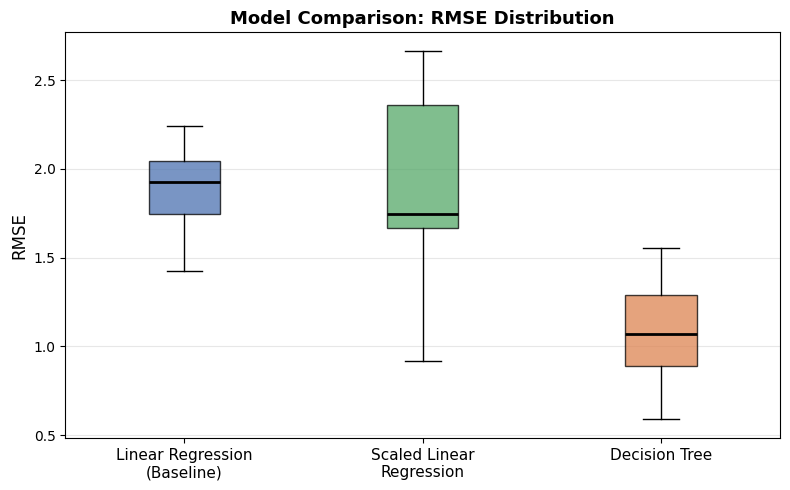

In [108]:
import matplotlib
import matplotlib.pyplot as plt

models_scores = {
    "Linear Regression\n(Baseline)": baseline_scores,
    "Scaled Linear\nRegression": scaled_scores,
    "Decision Tree": tree_scores,
}

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#55A868', '#DD8452']
bp = ax.boxplot([s for s in models_scores.values()], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(list(models_scores.keys()), fontsize=11)
ax.set_ylabel("RMSE", fontsize=12)
ax.set_title("Model Comparison: RMSE Distribution", fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The boxplot shows the full distribution of per-fold RMSE values across all 48 LOO-CV folds for each model, making it easy to compare both central tendency and spread.  

/Users/arya/Desktop/TERM8/COMP3202/Assignment 2/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.909e-01, tolerance: 1.501e-03
  model = cd_fast.enet_coordinate_descent(
/Users/arya/Desktop/TERM8/COMP3202/Assignment 2/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.021e-01, tolerance: 1.334e-03
  model = cd_fast.enet_coordinate_descent(
/Users/arya/Desktop/TERM8/COMP3202/Assignment 2/.venv/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the numbe

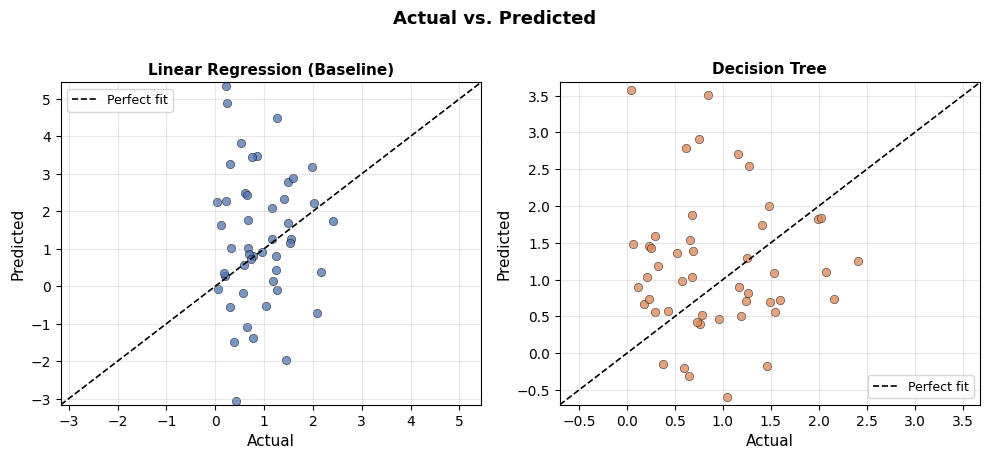

In [109]:
# Actual vs Predicted scatterplot
from sklearn.model_selection import cross_val_predict
y_pred_tree = cross_val_predict(tree_model, X, y, cv=cv)
y_pred_lr   = cross_val_predict(baseline_model, X, y, cv=cv)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, y_pred, name, color in zip(axes,
        [y_pred_lr, y_pred_tree],
        ["Linear Regression (Baseline)", "Decision Tree"],
        ['#4C72B0', '#DD8452']):
    ax.scatter(y, y_pred, color=color, alpha=0.75, edgecolors='k', linewidths=0.4)
    lims = [min(y.min(), y_pred.min())-0.1, max(y.max(), y_pred.max())+0.1]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit')
    ax.set_xlabel("Actual", fontsize=11)
    ax.set_ylabel("Predicted", fontsize=11)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle("Actual vs. Predicted", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The scatter plots show actual vs. predicted values for the baseline and the best-performing alternative. Points close to the dashed diagonal indicate accurate predictions.

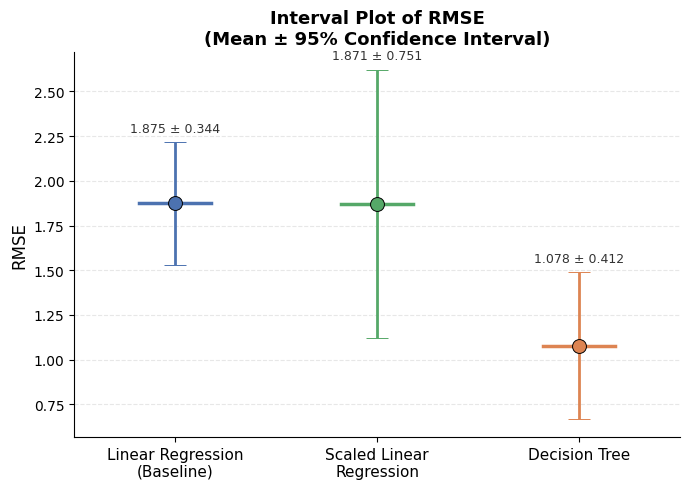

In [110]:
#Interval plot
from scipy import stats
import numpy as np

n = len(baseline_scores)
names_plot  = ["Linear Regression\n(Baseline)", "Scaled Linear\nRegression", "Decision Tree"]
all_scores  = [baseline_scores, scaled_scores, tree_scores]
colors_plot = ['#4C72B0', '#55A868', '#DD8452']

means = [s.mean() for s in all_scores]
stds  = [s.std()  for s in all_scores]
cis   = [stats.t.ppf(0.975, df=n-1) * s / np.sqrt(n) for s in stds]

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(names_plot))

for i, (m, ci, color) in enumerate(zip(means, cis, colors_plot)):
    ax.errorbar(x[i], m, yerr=ci, fmt='o', color=color,
                markersize=10, capsize=8, capthick=2, elinewidth=2,
                markeredgecolor='black', markeredgewidth=0.7, zorder=3)
    ax.plot([x[i]-0.18, x[i]+0.18], [m, m], color=color, linewidth=2.5, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(names_plot, fontsize=11)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Interval Plot of RMSE\n(Mean \u00b1 95% Confidence Interval)',
             fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_xlim(-0.5, len(names_plot)-0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, (m, ci) in enumerate(zip(means, cis)):
    ax.annotate(f"{m:.3f} \u00b1 {ci:.3f}", xy=(x[i], m + ci + 0.04),
                ha='center', va='bottom', fontsize=9, color='#333333')

plt.tight_layout()
plt.show()


The interval plot shows the mean RMSE for each model with 95% confidence intervals (computed from the t-distribution with n−1 degrees of freedom). Non-overlapping intervals shows meaningful difference in performance. The Decision Tree confidence interval does not overlap with those of either linear model, confirming its superior and more consistent performance.